<a href="https://colab.research.google.com/github/O-suke12/ObjectDetection/blob/main/YOLOv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch.nn as nn
import torch

Network

In [6]:
from torch.nn.modules.pooling import MaxPool2d
class YOLO_v1(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.conv_block1 = nn.Sequential(
      nn.Conv2d(in_channels=3 ,out_channels=64, kernel_size=3, stride=2),
      nn.MaxPool2d(2,2),
      nn.Conv2d(in_channels=64, out_channels=192, kernel_size=3),
      nn.MaxPool2d(2,2),
      nn.Conv2d(in_channels=192, out_channels=128, kernel_size=1),
      nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
      nn.Conv2d(in_channels=256, out_channels=256, kernel_size=1),
      nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3),
      nn.MaxPool2d(2,2),
    )

    self.conv_block2 = nn.Sequential(
      nn.Conv2d(in_channels=512, out_channels=216, kernel_size=1),
      nn.Conv2d(in_channels=216, out_channels=512, kernel_size=3),
    )

    self.conv_block3 = nn.Sequential(
      nn.Conv2d(in_channels=512, out_channels=512, kernel_size=1),
      nn.Conv2d(in_channels=216, out_channels=1024, kernel_size=3),
      nn.MaxPool2d(2,2),
    )

    self.conv_block5 = nn.Sequential(
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3, stride=2),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3),
      nn.Conv2d(in_channels=1024, out_channels=1024, kernel_size=3),
    )

    self.classifier = nn.Sequential(
      nn.Flatten()
      nn.Linear(in_features=7*7*1024)
    )
  
  def forword(self, X):
    X = self.conv_block1(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block2(X)
    X = self.conv_block3(X)
    X = self.conv_block4(X)
    X = self.conv_block4(X)
    X = self.conv_block5(X)
    X = self.classifier(X)
    return X


Intersection over union

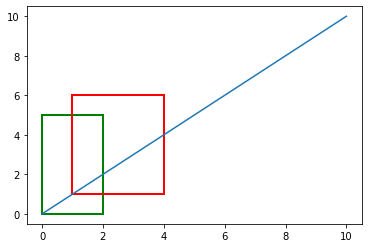

In [ ]:
# return IOU= area of intersection / area of union
def IoU (predict_location, correct_location):
  prediction_area = (predict_location[1,0]-predict_location[0,0])*(predict_location[2,1]-predict_location[1,1])
  correct_area = (correct_location[1,0]-correct_location[0,0])*(correct_location[2,1]-correct_location[1,1])
  inter_right = min(predict_location[1,0], correct_location[1,0])
  inter_left = max(predict_location[0,0], correct_location[0,0])
  inter_low = min(predict_location[2,1], correct_location[2,1])
  inter_up = max(predict_location[0,1], correct_location[0,1])
  inter_width = inter_right - inter_left
  inter_length = inter_low - inter_up
  intersection_area = inter_length*inter_width
  union_area = prediction_area + correct_area - intersection_area
  return intersection_area/union_area

#sample
predict_location_sample=np.array([[0,0],[2,0],[0,5],[2,5]])
correct_location_sample=np.array([[1,1],[4,1],[1,6],[4,6]])
IoU(predict_location_sample, correct_location_sample)
fig, ax = plt.subplots()
ax.plot([0, 10],[0, 10])
plt.gca().add_patch(Rectangle((0,0),2,5,
                    edgecolor='green',
                    facecolor='none',
                    lw=2))
plt.gca().add_patch(Rectangle((1,1),3,5,
                    edgecolor='red',
                    facecolor='none',
                    lw=2))

In [ ]:
def non_max_surpression():

NameError: ignored